First, import dependencies.

In [1]:
from cartopy import config
from dotenv import load_dotenv
from sodapy import Socrata

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import os 
import pandas as pd

Next, load API secrets from `.env` file.

In [2]:
load_dotenv() 

APP_TOKEN = os.environ['SOCRATA_APP_TOKEN']
APP_SECRET = os.environ['SOCRATA_APP_SECRET']

Create the Socrata client.

In [3]:
client = Socrata("data.seattle.gov", APP_TOKEN)

Let's fetch some data!

In [4]:
data = client.get("kzjm-xkqj", limit = 100)

Let's see what fields exist in each row...

In [5]:
data[0]

{'address': '308 N 68th St',
 'type': 'Auto Fire Alarm',
 'datetime': '2026-02-10T10:38:00.000',
 'latitude': '47.678734',
 'longitude': '-122.355241',
 'report_location': {'type': 'Point', 'coordinates': [-122.355241, 47.678734]},
 'incident_number': 'F260019283',
 ':@computed_region_ru88_fbhk': '47',
 ':@computed_region_kuhn_3gp2': '25',
 ':@computed_region_q256_3sug': '18377'}

In [6]:
df = pd.DataFrame.from_records(data)
df

,address,type,datetime,latitude,longitude,report_location,incident_number,:@computed_region_ru88_fbhk,:@computed_region_kuhn_3gp2,:@computed_region_q256_3sug,:@computed_region_2day_rhn5,:@computed_region_cyqu_gs94
0,308 N 68th St,Auto Fire Alarm,2026-02-10T10:38:00.000,47.678734,-122.355241,"{'type': 'Point', 'coordinates': [-122.355241,...",F260019283,47,25,18377,NaN,NaN
1,450 3rd Ave,Aid Response Yellow,2026-02-10T10:32:00.000,47.601886,-122.330511,"{'type': 'Point', 'coordinates': [-122.330511,...",F260019282,14,20,18379,NaN,NaN
2,515 3rd Ave,Medic Response,2026-02-10T10:30:00.000,47.602158,-122.330849,"{'type': 'Point', 'coordinates': [-122.330849,...",F260019281,14,20,18379,NaN,NaN
3,118 Broadway E,Auto Fire Alarm,2026-02-10T10:27:00.000,47.618943,-122.320857,"{'type': 'Point', 'coordinates': [-122.320857,...",F260019280,8,5,18376,NaN,NaN
4,750 Republican St,Medic Response,2026-02-10T10:20:00.000,47.623224,-122.342361,"{'type': 'Point', 'coordinates': [-122.342361,...",F260019279,56,7,18390,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1203 Ne 135th St,Aid Response,2026-02-10T02:03:00.000,47.726674,-122.315345,"{'type': 'Point', 'coordinates': [-122.315345,...",F260019144,46,26,19579,117,2
96,3rd Ave / Virginia St,Medic Response- Overdose,2026-02-10T01:56:00.000,47.612398,-122.340892,"{'type': 'Point', 'coordinates': [-122.340892,...",F260019142,56,31,18081,NaN,NaN
97,98 Union St,Aid Response,2026-02-10T01:51:00.000,47.607828,-122.339105,"{'type': 'Point', 'coordinates': [-122.339105,...",F260019141,14,30,18081,NaN,NaN
98,1401 5TH AVE W,Auto Fire Alarm,2026-02-10T01:43:00.000,47.631331,-122.363111,"{'type': 'Point', 'coordinates': [-122.363111,...",F260019140,50,39,19575,NaN,NaN


Can we iterate over the rows and plot the points on a map?

In [7]:
float(df["latitude"].min())

47.29567

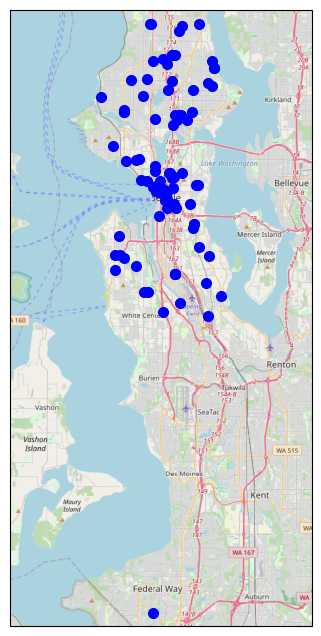

In [8]:
padding = 0.01
lon_min, lon_max = float(df["longitude"].min()) + padding * 10, float(df["longitude"].max()) - padding * 10
lat_min, lat_max = float(df["latitude"].min()) - padding, float(df["latitude"].max()) + padding

osm_tiles = cimgt.OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_image(osm_tiles, 11)

for datum in data:
    ax.plot(
        float(datum['longitude']), 
        float(datum['latitude']), 
        'bo', markersize=7, transform=ccrs.Geodetic()
    )

plt.show()

Neat! Now, SFD live has "richer" data than we have. They actually know which units were assigned to which event. Would it be possible for us to create a map of events that a specific unit responds to? And perhaps plot the route most likely taken between each event? To get an estimated sense of how far each unit drives every hour? That would be an interesting question to ask of the available data and one that could perhaps be useful for shift scheduling?

I'll look for the source of the response unit data!